## **XGBoost**

[1] Datos cargados: (328959, 85) en 4.2s
[1] Clases:
target
NoMeasure    162194
I            122387
A             29603
C              7334
B              3389
F              1677
G               766
J               682
E               248
H               213
D               189
Other           173
L               104
Name: count, dtype: int64

[2] Sizes → train:236850 val:26317 test:65792

--- Baseline ---
[0]	train-mlogloss:1.75441	val-mlogloss:1.75728
[50]	train-mlogloss:0.28724	val-mlogloss:0.35004
[100]	train-mlogloss:0.21972	val-mlogloss:0.34164
[137]	train-mlogloss:0.18557	val-mlogloss:0.34130
[Baseline] acc=0.8806, recall_macro=0.3075, f1_weighted=0.8631

--- ReducedComplexity ---
[0]	train-mlogloss:1.86933	val-mlogloss:1.87124
[50]	train-mlogloss:0.34667	val-mlogloss:0.37006
[100]	train-mlogloss:0.30723	val-mlogloss:0.35424
[150]	train-mlogloss:0.28230	val-mlogloss:0.34897
[200]	train-mlogloss:0.26337	val-mlogloss:0.34708
[219]	train-mlogloss:0.25753	val-mlogloss:0.34727
[Redu

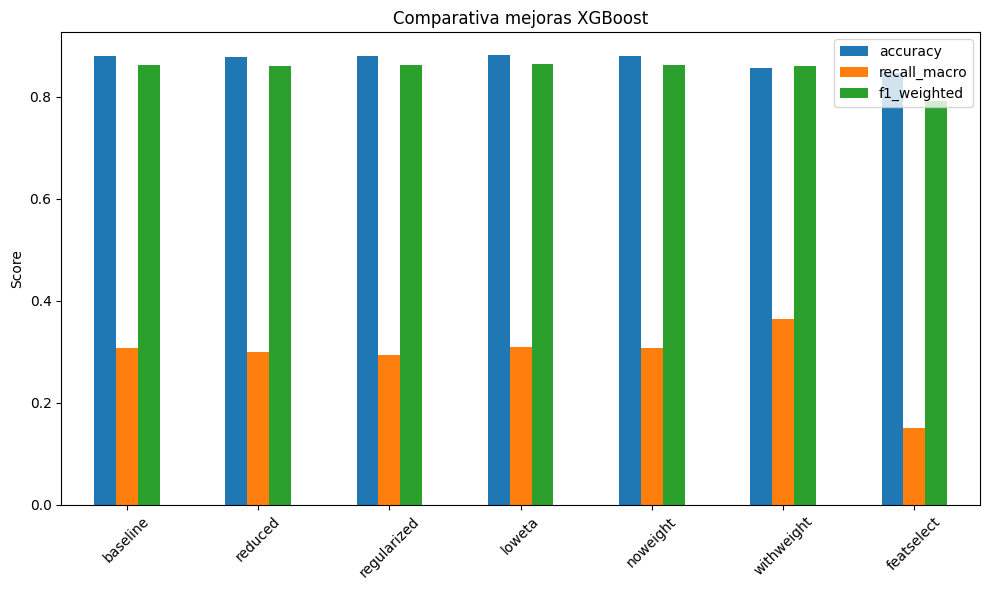

In [ ]:
# !pip install pandas numpy scikit-learn xgboost matplotlib -q

import os, time
import pandas as pd
import numpy as np
from collections import Counter
import xgboost as xgb
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ─────────── 1) Carga y target ───────────
os.environ["OMP_NUM_THREADS"]="8"
os.environ["OPENBLAS_NUM_THREADS"]="8"
os.environ["MKL_NUM_THREADS"]="8"

t0 = time.time()
df = pd.read_csv("todoscsvs_transformado.csv")
print(f"[1] Datos cargados: {df.shape} en {time.time()-t0:.1f}s")

measures = list("ABCDEFGHIJKLMNÑO")
df["target"] = df[measures].idxmax(axis=1)
df.loc[df[measures].sum(axis=1)==0, "target"] = "NoMeasure"
rare = df["target"].value_counts()[lambda s: s<100].index
df["target"] = df["target"].where(~df["target"].isin(rare), "Other")
print(f"[1] Clases:\n{df['target'].value_counts()}\n")

# ─────────── 2) Preprocesamiento ───────────
X = df.drop(columns=measures+["target"])
y_raw = df["target"]
le = LabelEncoder()
y = le.fit_transform(y_raw)

# imputar numéricos
num_cols = X.select_dtypes(include=np.number).columns
imp = SimpleImputer(strategy="median")
X[num_cols] = imp.fit_transform(X[num_cols])

# ordinal encode categóricos (si hay)
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
if cat_cols:
    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X[cat_cols] = oe.fit_transform(X[cat_cols].fillna("Missing"))

# ─────────── 3) Split train/val/test ───────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, stratify=y_train_full, random_state=1
)
print(f"[2] Sizes → train:{len(y_tr)} val:{len(y_val)} test:{len(y_test)}\n")

# sample weights
cw = Counter(y_tr)
sw_tr = np.array([ len(y_tr)/cw[c] for c in y_tr ])

# ─────────── helper de entrenamiento/eval ───────────
def train_eval(name, params, use_weight=False, features=None):
    print(f"--- {name} ---")
    # seleccionar features si aplica
    Xtrain = X_tr[features] if features else X_tr
    Xval   = X_val[features] if features else X_val
    Xtest  = X_test[features] if features else X_test

    dtrain = xgb.DMatrix(Xtrain.astype(np.float32), label=y_tr,
                         weight=sw_tr if use_weight else None)
    dval   = xgb.DMatrix(Xval.astype(np.float32),   label=y_val)
    dtest  = xgb.DMatrix(Xtest.astype(np.float32),  label=y_test)

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        evals=[(dtrain,"train"),(dval,"val")],
        early_stopping_rounds=20,
        verbose_eval=50
    )

    preds = np.argmax(bst.predict(dtest), axis=1)
    acc   = accuracy_score(y_test, preds)
    rec   = recall_score(y_test, preds, average="macro")
    f1w   = f1_score(y_test, preds, average="weighted")

    print(f"[{name}] acc={acc:.4f}, recall_macro={rec:.4f}, f1_weighted={f1w:.4f}\n")
    return bst, (acc, rec, f1w)

# ─────────── 4) Parámetros base ───────────
base = {
    "objective":        "multi:softprob",
    "num_class":        len(le.classes_),
    "eval_metric":      "mlogloss",
    "tree_method":      "hist",
    "eta":              0.2,
    "max_depth":        8,
    "subsample":        0.9,
    "colsample_bytree": 0.9,
    "lambda":           1,
    "alpha":            0,
    "seed":             42,
    "verbosity":        1
}

results = {}

# Baseline
bst0, results["baseline"] = train_eval("Baseline", base)

# Reduced complexity
p1 = base.copy()
p1.update({"max_depth":None, "max_leaves":32, "subsample":0.7, "colsample_bytree":0.7})
bst1, results["reduced"] = train_eval("ReducedComplexity", p1)

# Regularization
p2 = base.copy()
p2.update({"lambda":10, "alpha":5, "gamma":0.5})
bst2, results["regularized"] = train_eval("Regularized", p2)

# Lower eta
p3 = base.copy()
p3.update({"eta":0.05})
bst3, results["loweta"] = train_eval("LowerEta", p3)

# With vs Without weight
bst4a, results["noweight"] = train_eval("NoWeight", base, use_weight=False)
bst4b, results["withweight"] = train_eval("WithWeight", base, use_weight=True)

# Feature selection (>1% gain)
dtr_fs = xgb.DMatrix(X_tr.astype(np.float32), label=y_tr)
bst_fs = xgb.train(base, dtr_fs, num_boost_round=bst0.best_iteration+1, verbose_eval=False)
imp = bst_fs.get_score(importance_type="gain")
total_gain = sum(imp.values())
feats = [f for f,g in imp.items() if g/total_gain>=0.01]
print(f"[FeatureSel] keeping {len(feats)}/{X_tr.shape[1]} features\n")
bst5, results["featselect"] = train_eval("FeatureSelect", base, features=feats)

# ─────────── 5) Resumen ───────────
df_res = pd.DataFrame.from_dict(results, orient="index", columns=["accuracy","recall_macro","f1_weighted"])
print(df_res)

# ─────────── 6) Gráfico ───────────
df_res.plot.bar(figsize=(10,6))
plt.title("Comparativa mejoras XGBoost")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## **Pruebas post comparaciones**

[1] Datos cargados: (328959, 85) en 1.8s
[2] Split sizes train=236850, val=26317, test=65792

Entrenando modelo A (eta=0.05, sin pesos)...
[0]	train-mlogloss:2.36628	val-mlogloss:2.36668
[50]	train-mlogloss:0.55029	val-mlogloss:0.55288
[100]	train-mlogloss:0.40246	val-mlogloss:0.40993
[150]	train-mlogloss:0.36820	val-mlogloss:0.38101
[200]	train-mlogloss:0.34862	val-mlogloss:0.36868
[250]	train-mlogloss:0.33419	val-mlogloss:0.36160
[300]	train-mlogloss:0.32217	val-mlogloss:0.35636
[350]	train-mlogloss:0.31198	val-mlogloss:0.35265
[400]	train-mlogloss:0.30264	val-mlogloss:0.34953
[450]	train-mlogloss:0.29445	val-mlogloss:0.34707
[500]	train-mlogloss:0.28685	val-mlogloss:0.34501
[550]	train-mlogloss:0.27997	val-mlogloss:0.34368
[600]	train-mlogloss:0.27350	val-mlogloss:0.34254
[650]	train-mlogloss:0.26754	val-mlogloss:0.34163
[700]	train-mlogloss:0.26180	val-mlogloss:0.34090
[750]	train-mlogloss:0.25655	val-mlogloss:0.34022
[800]	train-mlogloss:0.25132	val-mlogloss:0.33965
[850]	train-ml

c:\Users\garci\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Evaluando en TEST...

--- Modelo A (LowerEta) ---
[ModelA] acc=0.8806, recall_macro=0.3042, f1_weighted=0.8625
              precision    recall  f1-score   support

           0     0.6104    0.2707    0.3751      5921
           1     0.6229    0.2729    0.3795       678
           2     0.5987    0.4383    0.5061      1467
           3     0.4400    0.2895    0.3492        38
           4     0.0000    0.0000    0.0000        50
           5     0.5294    0.1075    0.1787       335
           6     0.2778    0.0327    0.0585       153
           7     0.8000    0.0930    0.1667        43
           8     0.7944    0.9581    0.8686     24477
           9     0.8095    0.1250    0.2166       136
          10     0.5714    0.3810    0.4571        21
          11     0.9955    0.9857    0.9906     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                         0.8806     65792
   macro avg     0.5423    0.3042    0.3497     65792
weighted avg     0.867

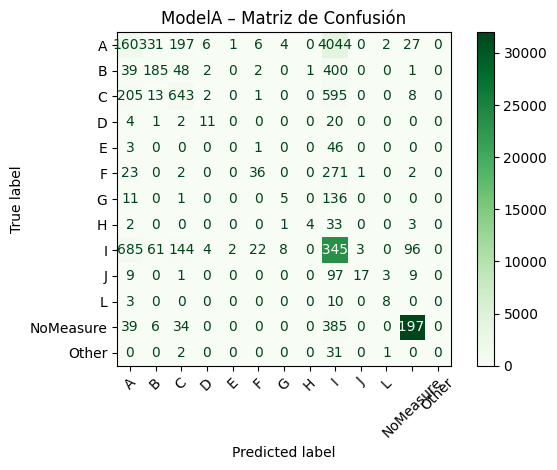


--- Modelo B (WithWeight) ---
[ModelB] acc=0.8403, recall_macro=0.4010, f1_weighted=0.8497
              precision    recall  f1-score   support

           0     0.3945    0.5774    0.4688      5921
           1     0.3435    0.4985    0.4067       678
           2     0.4563    0.7260    0.5604      1467
           3     0.3939    0.3421    0.3662        38
           4     0.1538    0.0400    0.0635        50
           5     0.2327    0.3015    0.2627       335
           6     0.2871    0.1895    0.2283       153
           7     0.5000    0.1628    0.2456        43
           8     0.8703    0.7488    0.8050     24477
           9     0.5370    0.2132    0.3053       136
          10     0.4286    0.4286    0.4286        21
          11     0.9960    0.9848    0.9904     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                         0.8403     65792
   macro avg     0.4303    0.4010    0.3947     65792
weighted avg     0.8679    0.8403    0.849

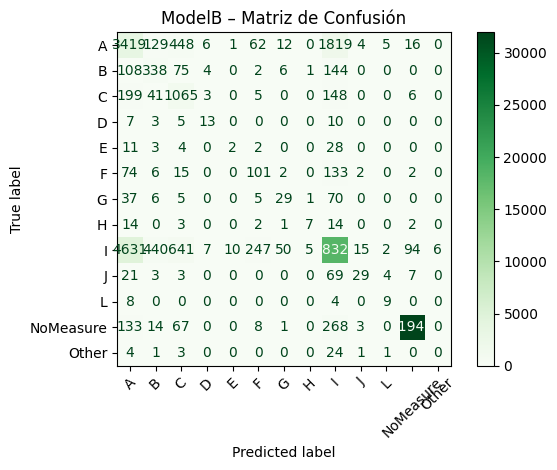


--- Blending (0.6*A + 0.4*B) ---
[Blending] acc=0.8776, recall_macro=0.3615, f1_weighted=0.8712
              precision    recall  f1-score   support

           0     0.5262    0.4074    0.4592      5921
           1     0.4895    0.3791    0.4273       678
           2     0.5464    0.6060    0.5747      1467
           3     0.4483    0.3421    0.3881        38
           4     0.2500    0.0200    0.0370        50
           5     0.4118    0.2090    0.2772       335
           6     0.3036    0.1111    0.1627       153
           7     0.6667    0.1395    0.2308        43
           8     0.8289    0.9015    0.8637     24477
           9     0.7667    0.1691    0.2771       136
          10     0.4737    0.4286    0.4500        21
          11     0.9955    0.9856    0.9905     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                         0.8776     65792
   macro avg     0.5159    0.3615    0.3952     65792
weighted avg     0.8692    0.8776    

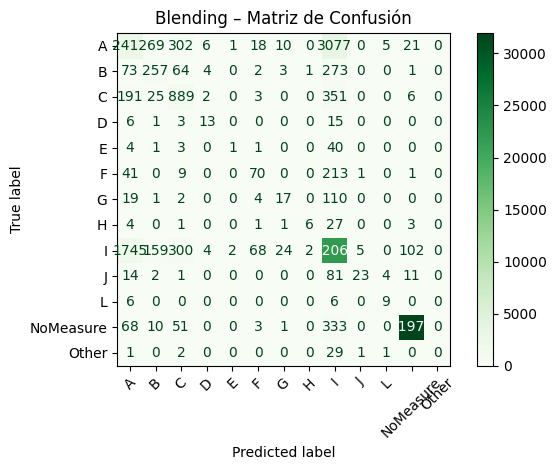


--- Stacking (LogisticRegression) ---
[Stacking] acc=0.8815, recall_macro=0.3003, f1_weighted=0.8668
              precision    recall  f1-score   support

           0     0.5886    0.3103    0.4063      5921
           1     0.5561    0.3363    0.4191       678
           2     0.5910    0.5003    0.5419      1467
           3     0.4545    0.2632    0.3333        38
           4     0.0000    0.0000    0.0000        50
           5     0.4945    0.1343    0.2113       335
           6     0.3571    0.0327    0.0599       153
           7     0.0000    0.0000    0.0000        43
           8     0.8051    0.9447    0.8693     24477
           9     0.9375    0.1103    0.1974       136
          10     0.7500    0.2857    0.4138        21
          11     0.9951    0.9862    0.9906     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                         0.8815     65792
   macro avg     0.5023    0.3003    0.3418     65792
weighted avg     0.8678    0.881

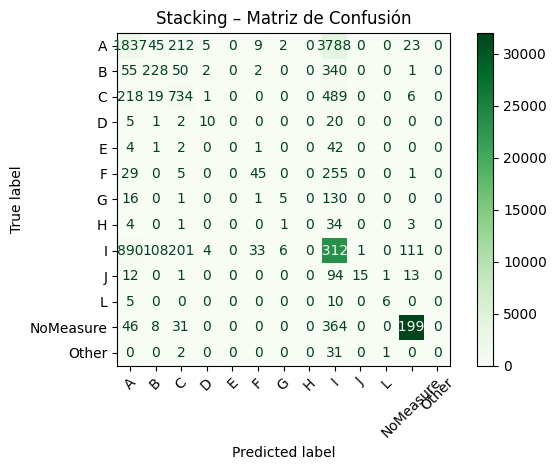

In [ ]:
# !pip install pandas numpy scikit-learn xgboost matplotlib -q

import os, time
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# ─── 1) Carga y target ─────────────────────────
os.environ["OMP_NUM_THREADS"]      = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"]      = "8"

t0 = time.time()
df = pd.read_csv("todoscsvs_transformado.csv")
print(f"[1] Datos cargados: {df.shape} en {time.time()-t0:.1f}s")

measures = list("ABCDEFGHIJKLMNÑO")
df["target"] = df[measures].idxmax(axis=1)
df.loc[df[measures].sum(axis=1)==0, "target"] = "NoMeasure"
rare = df["target"].value_counts()[lambda s: s<100].index
df["target"] = df["target"].where(~df["target"].isin(rare), "Other")

# ─── 2) Preprocesamiento ────────────────────────
X = df.drop(columns=measures+["target"])
y = LabelEncoder().fit_transform(df["target"])

# imputación numérica
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])

# ordinal encode categórico
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
if cat_cols:
    X[cat_cols] = OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1
    ).fit_transform(X[cat_cols].fillna("Missing"))

# ─── 3) Split train/val/test ─────────────────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1,
    stratify=y_train_full, random_state=1
)
print(f"[2] Split sizes train={len(y_tr)}, val={len(y_val)}, test={len(y_test)}\n")

# sample_weight para model B
cw = Counter(y_tr)
sw_tr = np.array([ len(y_tr)/cw[c] for c in y_tr ])

# DMatrix para validation y test (float32 para velocidad)
dval = xgb.DMatrix(X_val.astype(np.float32), label=y_val)
dtest= xgb.DMatrix(X_test.astype(np.float32), label=y_test)

# ─── 4) Configuración base de parámetros ─────────
base_params = {
    "objective":       "multi:softprob",
    "num_class":       len(np.unique(y)),
    "eval_metric":     "mlogloss",
    "tree_method":     "hist",
    "max_depth":       6,
    "subsample":       0.8,
    "colsample_bytree":0.8,
    "lambda":          5,
    "alpha":           1,
    "gamma":           0.1,
    "seed":            42,
    "verbosity":       0
}

# ─── 5) Entrenar modelo A (LowerEta) ────────────
print("Entrenando modelo A (eta=0.05, sin pesos)...")
dtrain_A = xgb.DMatrix(X_tr.astype(np.float32), label=y_tr)
params_A = base_params.copy()
params_A["eta"] = 0.05
bstA = xgb.train(
    params_A, dtrain_A, num_boost_round=1000,
    evals=[(dtrain_A,"train"),(dval,"val")],
    early_stopping_rounds=20, verbose_eval=50
)

# ─── 6) Entrenar modelo B (WithWeight) ──────────
print("\nEntrenando modelo B (eta=0.2, con sample_weight)...")
dtrain_B = xgb.DMatrix(
    X_tr.astype(np.float32), label=y_tr, weight=sw_tr
)
params_B = base_params.copy()
params_B["eta"] = 0.2
bstB = xgb.train(
    params_B, dtrain_B, num_boost_round=500,
    evals=[(dtrain_B,"train"),(dval,"val")],
    early_stopping_rounds=20, verbose_eval=50
)

# ─── 7) Generar meta‐características en VALIDATION ─
print("\nConstruyendo meta‐dataset (validation)...")
P_val_A = bstA.predict(dval)  # shape [n_val, n_class]
P_val_B = bstB.predict(dval)
meta_val = np.hstack([P_val_A, P_val_B])  # [n_val, 2*n_class]

# ─── 8) Entrenar meta‐modelo (LogisticRegression) ─
print("Entrenando meta‐modelo (logistic regression)...")
meta_clf = LogisticRegression(
    multi_class="multinomial", max_iter=500, solver="lbfgs"
).fit(meta_val, y_val)

# ─── 9) Evaluar base y ensemble en TEST ──────────
print("\nEvaluando en TEST...")
P_test_A = bstA.predict(dtest)
P_test_B = bstB.predict(dtest)
# ensamblado por blending
wA, wB = 0.6, 0.4
P_blend = wA*P_test_A + wB*P_test_B
y_pred_blend = np.argmax(P_blend, axis=1)
# stacking
meta_test = np.hstack([P_test_A, P_test_B])
y_pred_stack = meta_clf.predict(meta_test)

def report(name, y_true, y_pred):
    acc   = accuracy_score(y_true, y_pred)
    rec   = recall_score(y_true, y_pred, average="macro")
    f1w   = f1_score(y_true, y_pred, average="weighted")
    print(f"[{name}] acc={acc:.4f}, recall_macro={rec:.4f}, f1_weighted={f1w:.4f}")
    print(classification_report(y_true, y_pred, zero_division=0, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=LabelEncoder().fit(df["target"]).classes_)
    disp.plot(cmap="Greens", xticks_rotation=45)
    plt.title(f"{name} – Matriz de Confusión")
    plt.tight_layout()
    plt.show()

print("\n--- Modelo A (LowerEta) ---")
report("ModelA", y_test, np.argmax(P_test_A, axis=1))
print("\n--- Modelo B (WithWeight) ---")
report("ModelB", y_test, np.argmax(P_test_B, axis=1))
print("\n--- Blending (0.6*A + 0.4*B) ---")
report("Blending", y_test, y_pred_blend)
print("\n--- Stacking (LogisticRegression) ---")
report("Stacking", y_test, y_pred_stack)


## **Pruebas de ensamble**

In [ ]:
# !pip install pandas numpy scikit-learn xgboost matplotlib -q

import os, time
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

# ─── 1) Carga y target ─────────────────────────
os.environ["OMP_NUM_THREADS"]      = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"]      = "8"

df = pd.read_csv("todoscsvs_transformado.csv")
measures = list("ABCDEFGHIJKLMNÑO")
df["target"] = df[measures].idxmax(axis=1)
df.loc[df[measures].sum(axis=1)==0, "target"] = "NoMeasure"
rare = df["target"].value_counts()[lambda s: s<100].index
df["target"] = df["target"].where(~df["target"].isin(rare), "Other")

# ─── 2) Preprocesamiento ────────────────────────
X = df.drop(columns=measures+["target"])
y = LabelEncoder().fit_transform(df["target"])

# imputación numérica
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])

# ordinal encode categórico
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
if cat_cols:
    X[cat_cols] = OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1
    ).fit_transform(X[cat_cols].fillna("Missing"))

# ─── 3) Split train/val/test ─────────────────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1,
    stratify=y_train_full, random_state=1
)

# precompute sample_weight for multiclass Model B
cw = Counter(y_tr)
sw_tr = np.array([ len(y_tr)/cw[c] for c in y_tr ])

# DMatrix for validation & test
dval  = xgb.DMatrix(X_val.astype(np.float32),  label=y_val)
dtest = xgb.DMatrix(X_test.astype(np.float32), label=y_test)

# ─── 4) Entrena Model A (LowerEta) ──────────────
params_A = {
    "objective":        "multi:softprob",
    "num_class":        len(np.unique(y)),
    "eval_metric":      "mlogloss",
    "tree_method":      "hist",
    "eta":              0.05,
    "max_depth":        6,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "reg_lambda":       5,
    "reg_alpha":        1,
    "gamma":            0.1,
    "seed":             42,
    "verbosity":        0
}
dtrain_A = xgb.DMatrix(X_tr.astype(np.float32), label=y_tr)
bstA = xgb.train(
    params_A, dtrain_A, num_boost_round=1000,
    evals=[(dtrain_A,"train"), (dval,"val")],
    early_stopping_rounds=20, verbose_eval=100
)

# ─── 5) Entrena Model B (WithWeight) ────────────
params_B = params_A.copy()
params_B["eta"] = 0.2
dtrain_B = xgb.DMatrix(
    X_tr.astype(np.float32), label=y_tr, weight=sw_tr
)
bstB = xgb.train(
    params_B, dtrain_B, num_boost_round=500,
    evals=[(dtrain_B,"train"), (dval,"val")],
    early_stopping_rounds=20, verbose_eval=100
)

# ─── 6) Blending puro (A + B) ───────────────────
P_A = bstA.predict(dtest)
P_B = bstB.predict(dtest)
wA, wB = 0.6, 0.4
P_blend = wA * P_A + wB * P_B
y_blend = np.argmax(P_blend, axis=1)

# ─── 7) OVR para clases minoritarias ────────────
train_counts = Counter(y_tr)
med = np.median(list(train_counts.values()))
minor_cls = [cls for cls,cnt in train_counts.items() if cnt < med]

ovr_models = {}
alpha_ovr = 0.3
for cls in minor_cls:
    # etiqueta binaria
    y_bin = (y_tr == cls).astype(int)
    pos, neg = y_bin.sum(), len(y_bin) - y_bin.sum()
    wpos = len(y_bin) / pos
    wneg = len(y_bin) / neg
    sw_bin = np.where(y_bin==1, wpos, wneg)
    # xgb binario
    clf = xgb.XGBClassifier(
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="logloss",
        use_label_encoder=False,
        eta=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5,
        reg_alpha=1,
        gamma=0.1,
        random_state=cls,
        verbosity=0,
        n_jobs=8
    )
    clf.fit(X_tr, y_bin, sample_weight=sw_bin)
    ovr_models[cls] = clf

# aplicar votos extra
P_mix = P_blend.copy()
for cls, clf in ovr_models.items():
    p_cls = clf.predict_proba(X_test)[:,1]
    P_mix[:,cls] += alpha_ovr * p_cls
y_blend_ovr = np.argmax(P_mix, axis=1)

# ─── 8) Bagging de Model B ──────────────────────
bag_seeds = [1,2,3,4,5]
P_bag = np.zeros_like(P_B)
for sd in bag_seeds:
    dtrain = xgb.DMatrix(
        X_tr.astype(np.float32), label=y_tr,
        weight=sw_tr  # mantengo igual
    )
    params_B["seed"] = sd
    bst = xgb.train(
        params_B, dtrain, num_boost_round=bstB.best_iteration,
        evals=[(dtrain,"train"), (dval,"val")],
        early_stopping_rounds=20, verbose_eval=False
    )
    P_bag += bst.predict(dtest)
P_bag /= len(bag_seeds)
y_bag = np.argmax(P_bag, axis=1)

# ─── 9) Reporta métricas ────────────────────────
def report(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("acc          =", accuracy_score(y_true, y_pred))
    print("recall_macro =", recall_score(y_true, y_pred, average="macro"))
    print("f1_weighted  =", f1_score(y_true, y_pred, average="weighted"))
    print(classification_report(y_true, y_pred, zero_division=0, digits=4))

report("ModelA",    y_test, np.argmax(P_A, axis=1))
report("ModelB",    y_test, np.argmax(P_B, axis=1))
report("Blending",  y_test, y_blend)
report("Blend+OVR", y_test, y_blend_ovr)
report("BaggingB",  y_test, y_bag)


[0]	train-mlogloss:2.36628	val-mlogloss:2.36668
[100]	train-mlogloss:0.40246	val-mlogloss:0.40993
[200]	train-mlogloss:0.34862	val-mlogloss:0.36868
[300]	train-mlogloss:0.32217	val-mlogloss:0.35636
[400]	train-mlogloss:0.30264	val-mlogloss:0.34953
[500]	train-mlogloss:0.28685	val-mlogloss:0.34501
[600]	train-mlogloss:0.27350	val-mlogloss:0.34254
[700]	train-mlogloss:0.26180	val-mlogloss:0.34090
[800]	train-mlogloss:0.25132	val-mlogloss:0.33965
[900]	train-mlogloss:0.24152	val-mlogloss:0.33892
[999]	train-mlogloss:0.23293	val-mlogloss:0.33861
[0]	train-mlogloss:2.15232	val-mlogloss:2.36153
[100]	train-mlogloss:0.31548	val-mlogloss:0.62183
[200]	train-mlogloss:0.18558	val-mlogloss:0.50854
[300]	train-mlogloss:0.13385	val-mlogloss:0.46120
[400]	train-mlogloss:0.10480	val-mlogloss:0.43786
[499]	train-mlogloss:0.08554	val-mlogloss:0.42430

=== ModelA ===
acc          = 0.880638983463035
recall_macro = 0.3041780043455746
f1_weighted  = 0.8624639638174008
              precision    recall  f1

## **Algoritmo Elegido**

=== Blend + OVR ===
Accuracy       : 0.8772647130350194
Recall macro   : 0.3780342990722048
F1 weighted    : 0.8711355562882906

Classification Report:
              precision    recall  f1-score   support

           0     0.5271    0.4064    0.4589      5921
           1     0.4895    0.3791    0.4273       678
           2     0.5464    0.6060    0.5747      1467
           3     0.3889    0.3684    0.3784        38
           4     0.2308    0.0600    0.0952        50
           5     0.4107    0.2060    0.2744       335
           6     0.3036    0.1111    0.1627       153
           7     0.4737    0.2093    0.2903        43
           8     0.8293    0.9006    0.8635     24477
           9     0.5091    0.2059    0.2932       136
          10     0.3571    0.4762    0.4082        21
          11     0.9955    0.9856    0.9905     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                         0.8773     65792
   macro avg     0.4663    0.3780   

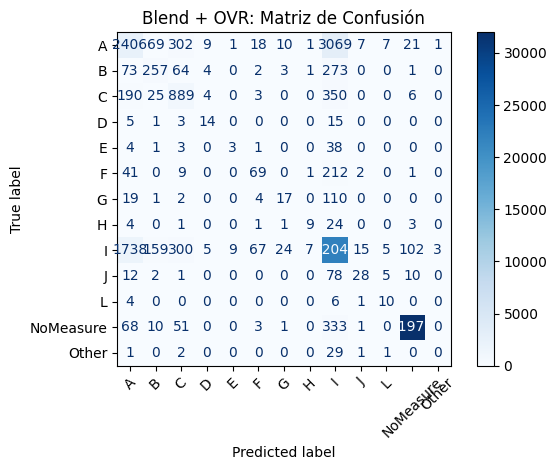

In [ ]:
# !pip install pandas numpy scikit-learn xgboost matplotlib -q

import os, time
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# ─── 1) Carga y target ─────────────────────────
os.environ["OMP_NUM_THREADS"]      = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"]      = "8"

df = pd.read_csv("todoscsvs_transformado.csv")
measures = list("ABCDEFGHIJKLMNÑO")
df["target"] = df[measures].idxmax(axis=1)
df.loc[df[measures].sum(axis=1)==0, "target"] = "NoMeasure"
rare = df["target"].value_counts()[lambda s: s<100].index
df["target"] = df["target"].where(~df["target"].isin(rare), "Other")

# ─── 2) Preprocesamiento ────────────────────────
X = df.drop(columns=measures+["target"])
y = LabelEncoder().fit_transform(df["target"])

# imputación numérica
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])

# ordinal encode categórico
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
if cat_cols:
    X[cat_cols] = OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1
    ).fit_transform(X[cat_cols].fillna("Missing"))

# ─── 3) Split train/val/test ─────────────────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1,
    stratify=y_train_full, random_state=1
)

# sample_weight para Model B
cw = Counter(y_tr)
sw_tr = np.array([ len(y_tr)/cw[c] for c in y_tr ])

# DMatrix para val/test
dval  = xgb.DMatrix(X_val.astype(np.float32),  label=y_val)
dtest = xgb.DMatrix(X_test.astype(np.float32), label=y_test)

# ─── 4) Entrena Model A (eta=0.05) ──────────────
params_A = {
    "objective":"multi:softprob", "num_class":len(np.unique(y)),
    "eval_metric":"mlogloss", "tree_method":"hist",
    "eta":0.05, "max_depth":6,
    "subsample":0.8, "colsample_bytree":0.8,
    "reg_lambda":5, "reg_alpha":1, "gamma":0.1,
    "seed":42, "verbosity":0
}
dtrain_A = xgb.DMatrix(X_tr.astype(np.float32), label=y_tr)
bstA = xgb.train(
    params_A, dtrain_A, num_boost_round=1000,
    evals=[(dtrain_A,"train"), (dval,"val")],
    early_stopping_rounds=20, verbose_eval=False
)

# ─── 5) Entrena Model B (eta=0.2 + weights) ─────
params_B = params_A.copy(); params_B["eta"]=0.2
dtrain_B = xgb.DMatrix(X_tr.astype(np.float32), label=y_tr, weight=sw_tr)
bstB = xgb.train(
    params_B, dtrain_B, num_boost_round=500,
    evals=[(dtrain_B,"train"), (dval,"val")],
    early_stopping_rounds=20, verbose_eval=False
)

# ─── 6) Blending (0.6·A + 0.4·B) ───────────────
P_A = bstA.predict(dtest)
P_B = bstB.predict(dtest)
P_blend = 0.6*P_A + 0.4*P_B
y_blend = np.argmax(P_blend, axis=1)

# ─── 7) OVR votos extra para minorías ────────────
train_counts = Counter(y_tr)
med = np.median(list(train_counts.values()))
minor_cls = [c for c,n in train_counts.items() if n < med]
alpha_ovr = 0.3
ovr_models = {}
for cls in minor_cls:
    y_bin = (y_tr==cls).astype(int)
    wpos = len(y_tr)/y_bin.sum()
    wneg = len(y_tr)/(len(y_tr)-y_bin.sum())
    sw_bin = np.where(y_bin==1, wpos, wneg)
    clf = xgb.XGBClassifier(
        objective="binary:logistic", tree_method="hist",
        eval_metric="logloss", eta=0.1, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=5, reg_alpha=1, gamma=0.1,
        random_state=cls, use_label_encoder=False,
        verbosity=0, n_jobs=8
    )
    clf.fit(X_tr, y_bin, sample_weight=sw_bin)
    ovr_models[cls] = clf

P_mix = P_blend.copy()
for cls, clf in ovr_models.items():
    P_mix[:,cls] += alpha_ovr * clf.predict_proba(X_test)[:,1]
y_blend_ovr = np.argmax(P_mix, axis=1)

# ─── 8) Métricas y matriz de confusión ──────────
print("=== Blend + OVR ===")
print("Accuracy       :", accuracy_score(y_test, y_blend_ovr))
print("Recall macro   :", recall_score(y_test, y_blend_ovr, average="macro"))
print("F1 weighted    :", f1_score(y_test, y_blend_ovr, average="weighted"))
print("\nClassification Report:")
print(classification_report(y_test, y_blend_ovr, zero_division=0, digits=4))

cm = confusion_matrix(y_test, y_blend_ovr)
disp = ConfusionMatrixDisplay(cm, display_labels=LabelEncoder().fit(df["target"]).classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Blend + OVR: Matriz de Confusión")
plt.tight_layout()
plt.show()


## **HistGradientBoost**

Datos cargados: (328959, 85) en 1.7s
Split sizes → train=236850, val=26317, test=65792


--- Baseline ---
Accuracy:      0.8488
Recall_macro:  0.2753
F1_weighted:   0.8194
              precision    recall  f1-score   support

           0     0.6576    0.0532    0.0984      5921
           1     0.5391    0.2847    0.3726       678
           2     0.5738    0.2359    0.3343      1467
           3     0.0562    0.1316    0.0787        38
           4     0.0174    0.0400    0.0242        50
           5     0.2727    0.1075    0.1542       335
           6     0.1236    0.1438    0.1329       153
           7     0.0267    0.0465    0.0339        43
           8     0.7492    0.9556    0.8399     24477
           9     0.1148    0.1029    0.1085       136
          10     0.0137    0.4762    0.0266        21
          11     0.9977    0.9713    0.9843     32439
          12     0.0095    0.0294    0.0144        34

    accuracy                         0.8488     65792
   macro avg    

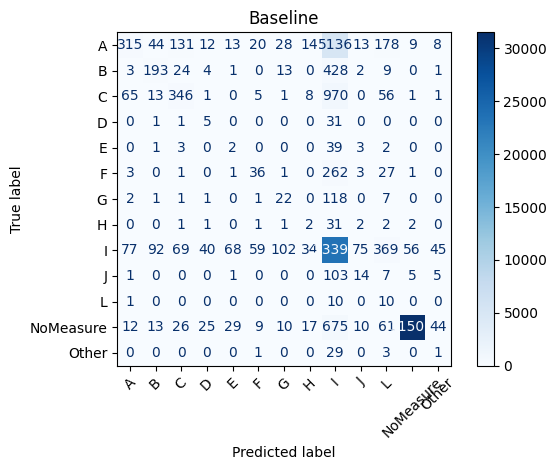


--- WithSqrtWeight ---
Accuracy:      0.8529
Recall_macro:  0.4155
F1_weighted:   0.8548
              precision    recall  f1-score   support

           0     0.4613    0.3751    0.4137      5921
           1     0.3433    0.5059    0.4091       678
           2     0.4350    0.6871    0.5328      1467
           3     0.2281    0.3421    0.2737        38
           4     0.0732    0.1800    0.1040        50
           5     0.2610    0.2836    0.2718       335
           6     0.1616    0.3137    0.2133       153
           7     0.1154    0.2093    0.1488        43
           8     0.8346    0.8367    0.8357     24477
           9     0.1667    0.1985    0.1812       136
          10     0.2368    0.4286    0.3051        21
          11     0.9974    0.9818    0.9895     32439
          12     0.0274    0.0588    0.0374        34

    accuracy                         0.8529     65792
   macro avg     0.3340    0.4155    0.3628     65792
weighted avg     0.8594    0.8529    0.8548 

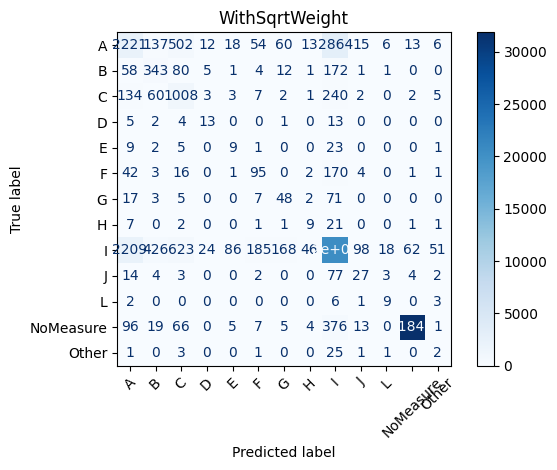


--- Blending 0.7·A + 0.3·B ---
Accuracy:      0.8544
Recall_macro:  0.3006
F1_weighted:   0.8322


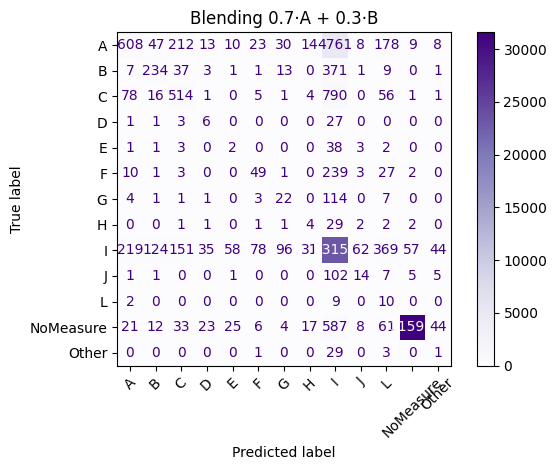


Umbral para clase 0 con recall>=0.5: 0.000
After threshold-moving:
Recall_macro: 0.0769
Accuracy:     0.0900



In [ ]:
# !pip install pandas numpy scikit-learn matplotlib -q

import os, time
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import HistGradientBoostingClassifier
import matplotlib.pyplot as plt

# ─── 1) Carga y creación del target ─────────────────────────
os.environ["OMP_NUM_THREADS"]="8"
os.environ["OPENBLAS_NUM_THREADS"]="8"
os.environ["MKL_NUM_THREADS"]="8"

t0 = time.time()
df = pd.read_csv("todoscsvs_transformado.csv")
print(f"Datos cargados: {df.shape} en {time.time()-t0:.1f}s")

measures = list("ABCDEFGHIJKLMNÑO")
df["target"] = df[measures].idxmax(axis=1)
df.loc[df[measures].sum(axis=1)==0, "target"] = "NoMeasure"
rare = df["target"].value_counts()[lambda s: s<100].index
df["target"] = df["target"].where(~df["target"].isin(rare), "Other")

# ─── 2) Preprocesamiento ────────────────────────────────
X = df.drop(columns=measures+["target"])
y = LabelEncoder().fit_transform(df["target"])

# 2.1 imputación numérica
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])

# 2.2 ordinal encode categóricas
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
if cat_cols:
    X[cat_cols] = OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1
    ).fit_transform(X[cat_cols].fillna("Missing"))

# ─── 3) Split train/val/test ────────────────────────────
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1,
    stratify=y_train_full, random_state=1
)
print(f"Split sizes → train={len(y_tr)}, val={len(y_val)}, test={len(y_test)}\n")

# ─── 4) Sample weights (moderados) ───────────────────────
train_counts = Counter(y_tr)
total = len(y_tr)
# sqrt weighting: suaviza extremos
sw = np.array([ np.sqrt(total/train_counts[c]) for c in y_tr ])

# ─── helper para plot y métricas ────────────────────────
def evaluate(name, model, Xtr, ytr, Xte, yte, weights=None):
    print(f"\n--- {name} ---")
    if weights is not None:
        model.fit(Xtr, ytr, sample_weight=weights)
    else:
        model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    print(f"Accuracy:      {accuracy_score(yte,preds):.4f}")
    print(f"Recall_macro:  {recall_score(yte,preds,average='macro'):.4f}")
    print(f"F1_weighted:   {f1_score(yte,preds,average='weighted'):.4f}")
    print(classification_report(yte, preds, zero_division=0, digits=4))
    cm = confusion_matrix(yte, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=LabelEncoder().fit(df["target"]).classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(name)
    plt.tight_layout()
    plt.show()
    # return probabilities if available
    if hasattr(model, "predict_proba"):
        return model.predict_proba(Xte)
    else:
        return None

# ─── 5) Modelos a probar ───────────────────────────────
params = {
    "loss":"log_loss",
    "max_iter":100,
    "early_stopping":True,
    "validation_fraction":0.1,
    "n_iter_no_change":10,
    "random_state":42
}

# A) Baseline
hgb_A = HistGradientBoostingClassifier(**params)
P_A = evaluate("Baseline", hgb_A, X_tr, y_tr, X_test, y_test)

# B) Con sample weights moderados
hgb_B = HistGradientBoostingClassifier(**params)
P_B = evaluate("WithSqrtWeight", hgb_B, X_tr, y_tr, X_test, y_test, weights=sw)

# C) Blending (0.7 A + 0.3 B)
print("\n--- Blending 0.7·A + 0.3·B ---")
P_blend = 0.7*P_A + 0.3*P_B
y_blend = np.argmax(P_blend, axis=1)
print(f"Accuracy:      {accuracy_score(y_test,y_blend):.4f}")
print(f"Recall_macro:  {recall_score(y_test,y_blend,average='macro'):.4f}")
print(f"F1_weighted:   {f1_score(y_test,y_blend,average='weighted'):.4f}")
cm = confusion_matrix(y_test, y_blend)
disp = ConfusionMatrixDisplay(cm, display_labels=LabelEncoder().fit(df["target"]).classes_)
disp.plot(cmap="Purples", xticks_rotation=45)
plt.title("Blending 0.7·A + 0.3·B")
plt.tight_layout()
plt.show()

# ─── 6) Threshold-moving para una clase de ejemplo ──────
# (ajusta umbral para la clase 'A' = label index 0 por ejemplo)
cls = 0
probs = P_B[:,cls]
from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve((y_test==cls).astype(int), probs)
# elige umbral para recall >= 0.5
idx = np.where(rec>=0.5)[0]
best_thr = thr[idx[0]] if idx.size else 0.5
print(f"\nUmbral para clase {cls} con recall>=0.5: {best_thr:.3f}")
# aplicar umbral simple
y_adj = y_blend.copy()
y_adj[probs>=best_thr] = cls
print("After threshold-moving:")
print(f"Recall_macro: {recall_score(y_test,y_adj,average='macro'):.4f}")
print(f"Accuracy:     {accuracy_score(y_test,y_adj):.4f}\n")


## **Algoritmo Elegido, withsqrtweight**

## **Random Forest**

Datos cargados: (328959, 85) en 1.5s
Split sizes → train=236850, val=26317, test=65792

--- Baseline ---
Accuracy     : 0.8703033803501945
Recall_macro : 0.21827041554219576
F1_weighted  : 0.8406752053984697
              precision    recall  f1-score   support

           0     0.6695    0.1711    0.2725      5921
           1     0.7442    0.1416    0.2379       678
           2     0.6534    0.2468    0.3582      1467
           3     0.5000    0.0263    0.0500        38
           4     0.0000    0.0000    0.0000        50
           5     0.8182    0.0269    0.0520       335
           6     0.0000    0.0000    0.0000       153
           7     0.6000    0.0698    0.1250        43
           8     0.7569    0.9848    0.8560     24477
           9     1.0000    0.0515    0.0979       136
          10     0.7500    0.1429    0.2400        21
          11     0.9981    0.9760    0.9869     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                      

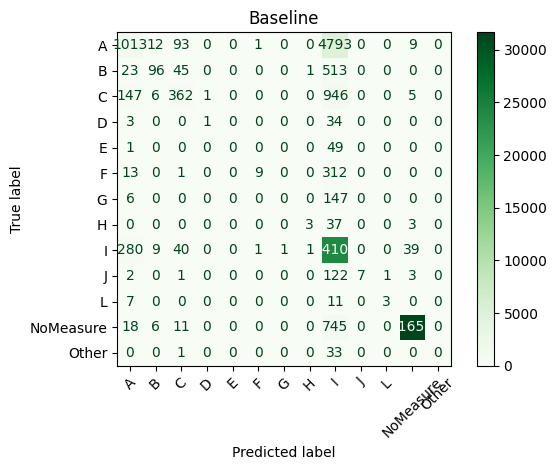


--- BalancedSubsample ---
Accuracy     : 0.8587518239299611
Recall_macro : 0.23777653834483087
F1_weighted  : 0.8253945187115892
              precision    recall  f1-score   support

           0     0.7321    0.1140    0.1973      5921
           1     0.7557    0.1460    0.2447       678
           2     0.6608    0.2577    0.3708      1467
           3     0.4737    0.2368    0.3158        38
           4     0.0000    0.0000    0.0000        50
           5     0.8667    0.0388    0.0743       335
           6     0.0000    0.0000    0.0000       153
           7     0.8000    0.0930    0.1667        43
           8     0.7351    0.9904    0.8439     24477
           9     0.9000    0.0662    0.1233       136
          10     0.6667    0.1905    0.2963        21
          11     0.9978    0.9576    0.9773     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                         0.8588     65792
   macro avg     0.5837    0.2378    0.2777     65792
weig

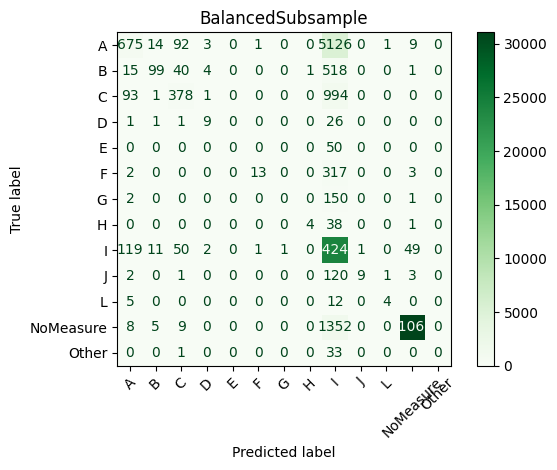


--- DeepForest ---
Accuracy     : 0.8717321254863813
Recall_macro : 0.3533808153689349
F1_weighted  : 0.856053446637575
              precision    recall  f1-score   support

           0     0.6236    0.2420    0.3487      5921
           1     0.4833    0.3850    0.4286       678
           2     0.5641    0.5222    0.5423      1467
           3     0.3030    0.2632    0.2817        38
           4     0.3750    0.0600    0.1034        50
           5     0.4701    0.1881    0.2687       335
           6     0.2366    0.2876    0.2596       153
           7     0.5333    0.1860    0.2759        43
           8     0.7847    0.9517    0.8602     24477
           9     0.7000    0.2059    0.3182       136
          10     0.5385    0.3333    0.4118        21
          11     0.9986    0.9690    0.9836     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                         0.8717     65792
   macro avg     0.5085    0.3534    0.3910     65792
weighted avg 

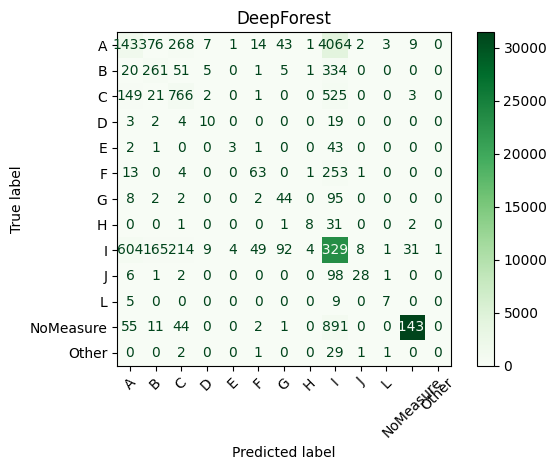


--- ShallowForest ---
Accuracy     : 0.5860742947470817
Recall_macro : 0.5029003827661154
F1_weighted  : 0.6473329722403657
              precision    recall  f1-score   support

           0     0.2960    0.1956    0.2355      5921
           1     0.0951    0.7257    0.1681       678
           2     0.2546    0.5999    0.3575      1467
           3     0.2022    0.4737    0.2835        38
           4     0.0100    0.4600    0.0197        50
           5     0.0282    0.5522    0.0537       335
           6     0.0637    0.4771    0.1124       153
           7     0.0068    0.4419    0.0135        43
           8     0.8522    0.2580    0.3960     24477
           9     0.0197    0.2647    0.0367       136
          10     0.0820    0.7143    0.1471        21
          11     1.0000    0.9042    0.9497     32439
          12     0.0097    0.4706    0.0190        34

    accuracy                         0.5861     65792
   macro avg     0.2246    0.5029    0.2148     65792
weighted 

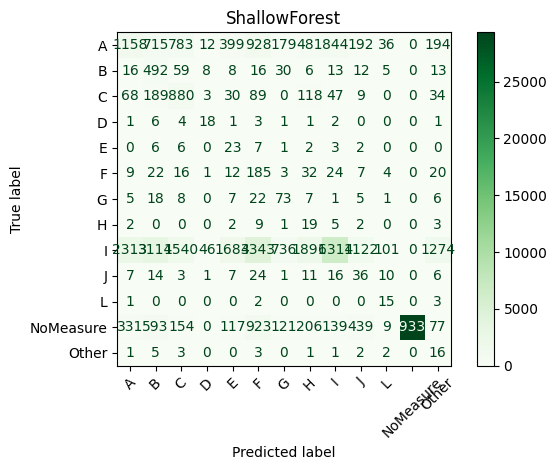


--- SqrtWeight ---
Accuracy     : 0.870136186770428
Recall_macro : 0.23471119560597384
F1_weighted  : 0.8405431255482514
              precision    recall  f1-score   support

           0     0.7023    0.1586    0.2587      5921
           1     0.7041    0.1755    0.2810       678
           2     0.6339    0.2856    0.3938      1467
           3     0.4545    0.1316    0.2041        38
           4     0.0000    0.0000    0.0000        50
           5     0.8333    0.0448    0.0850       335
           6     0.0000    0.0000    0.0000       153
           7     0.8000    0.0930    0.1667        43
           8     0.7560    0.9871    0.8563     24477
           9     1.0000    0.0588    0.1111       136
          10     0.6000    0.1429    0.2308        21
          11     0.9986    0.9733    0.9858     32439
          12     0.0000    0.0000    0.0000        34

    accuracy                         0.8701     65792
   macro avg     0.5756    0.2347    0.2749     65792
weighted avg

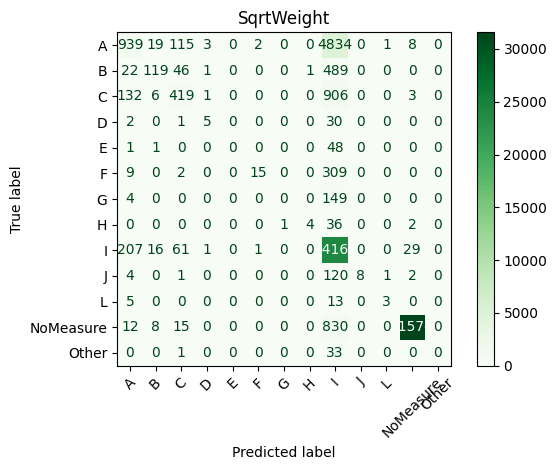


--- Blending 0.6·Baseline + 0.4·SqrtWeight ---
Blend Accuracy     : 0.8704097762645915
Blend Recall_macro : 0.22790287693426434
Blend F1_weighted  : 0.8403249767349132


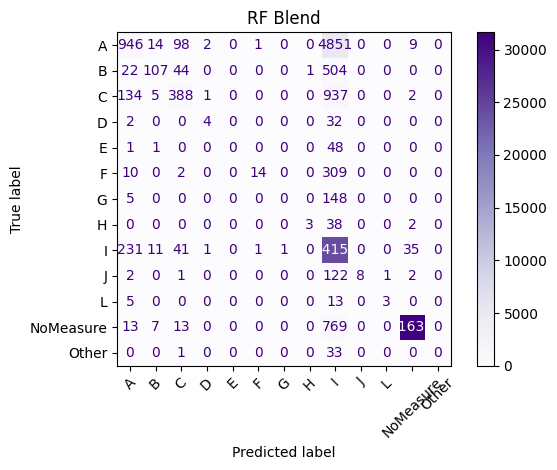

In [ ]:
# !pip install pandas numpy scikit-learn matplotlib -q

import os, time
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ─── 1) Configurar uso de 8 núcleos ──────────────────────────
os.environ["OMP_NUM_THREADS"]      = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"]      = "8"

# ─── 2) Carga de datos y creación del target ─────────────────
t0 = time.time()
df = pd.read_csv("todoscsvs_transformado.csv")
print(f"Datos cargados: {df.shape} en {time.time()-t0:.1f}s")

measures = list("ABCDEFGHIJKLMNÑO")
df["target"] = df[measures].idxmax(axis=1)
df.loc[df[measures].sum(axis=1)==0, "target"] = "NoMeasure"
rare = df["target"].value_counts()[lambda s: s<100].index
df["target"] = df["target"].where(~df["target"].isin(rare), "Other")

# ─── 3) Preprocesamiento ────────────────────────────────────
X = df.drop(columns=measures + ["target"])
y = LabelEncoder().fit_transform(df["target"])

# 3.1 Imputar numéricos
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])

# 3.2 Ordinal encode categóricas
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
if cat_cols:
    X[cat_cols] = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ).fit_transform(X[cat_cols].fillna("Missing"))

# ─── 4) Split train/val/test ────────────────────────────────
X_full, X_test, y_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.1,
    stratify=y_full, random_state=1
)
print(f"Split sizes → train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")

# ─── 5) Sample weights “sqrt” ──────────────────────────────
counts = Counter(y_train)
total = len(y_train)
sqrt_weights = np.array([np.sqrt(total/counts[c]) for c in y_train])

# ─── 6) Helper de evaluación ───────────────────────────────
def evaluate(name, clf, Xtr, ytr, Xte, yte, sw=None):
    print(f"\n--- {name} ---")
    if sw is not None:
        clf.fit(Xtr, ytr, sample_weight=sw)
    else:
        clf.fit(Xtr, ytr)
    preds = clf.predict(Xte)
    print("Accuracy     :", accuracy_score(yte, preds))
    print("Recall_macro :", recall_score(yte, preds, average='macro'))
    print("F1_weighted  :", f1_score(yte, preds, average='weighted'))
    print(classification_report(yte, preds, zero_division=0, digits=4))
    cm = confusion_matrix(yte, preds)
    disp = ConfusionMatrixDisplay(cm,
        display_labels=LabelEncoder().fit(df["target"]).classes_)
    disp.plot(cmap="Greens", xticks_rotation=45)
    plt.title(name)
    plt.tight_layout()
    plt.show()

# ─── 7) Configuraciones de RandomForest ────────────────────
rf_configs = {
    "Baseline": {
        "n_estimators": 200, "max_depth": None,
        "max_features": "sqrt", "class_weight": None
    },
    "BalancedSubsample": {
        "n_estimators": 300, "max_depth": None,
        "max_features": "sqrt", "class_weight": "balanced_subsample"
    },
    "DeepForest": {
        "n_estimators": 200, "max_depth": 25,
        "max_features": 0.5, "class_weight": "balanced_subsample"
    },
    "ShallowForest": {
        "n_estimators": 500, "max_depth": 8,
        "max_features": 0.7, "min_samples_leaf": 2,
        "class_weight": "balanced_subsample"
    },
    "SqrtWeight": {  # se usará sample_weight
        "n_estimators": 300, "max_depth": None,
        "max_features": "sqrt", "class_weight": None
    }
}

# ─── 8) Entrenar y evaluar cada RF ────────────────────────
for name, params in rf_configs.items():
    rf = RandomForestClassifier(random_state=42, n_jobs=8, **params)
    if name == "SqrtWeight":
        evaluate(name, rf, X_train, y_train, X_test, y_test, sw=sqrt_weights)
    else:
        evaluate(name, rf, X_train, y_train, X_test, y_test)

# ─── 9) Blending Baseline + SqrtWeight ────────────────────
print("\n--- Blending 0.6·Baseline + 0.4·SqrtWeight ---")
rf_base = RandomForestClassifier(random_state=42, n_jobs=8, **rf_configs["Baseline"])
rf_wt   = RandomForestClassifier(random_state=42, n_jobs=8, **rf_configs["SqrtWeight"])
rf_base.fit(X_train, y_train)
rf_wt.fit(X_train, y_train, sample_weight=sqrt_weights)
P_base = rf_base.predict_proba(X_test)
P_wt   = rf_wt.predict_proba(X_test)
P_blend= 0.6 * P_base + 0.4 * P_wt
y_blend= np.argmax(P_blend, axis=1)
print("Blend Accuracy     :", accuracy_score(y_test, y_blend))
print("Blend Recall_macro :", recall_score(y_test, y_blend, average='macro'))
print("Blend F1_weighted  :", f1_score(y_test, y_blend, average='weighted'))
cm = confusion_matrix(y_test, y_blend)
disp = ConfusionMatrixDisplay(cm,
    display_labels=LabelEncoder().fit(df["target"]).classes_)
disp.plot(cmap="Purples", xticks_rotation=45)
plt.title("RF Blend")
plt.tight_layout()
plt.show()


## **DeepForest elegido**

Datos cargados: (328959, 85) en 1.6s
Split sizes → train=263167, test=65792
DeepForest entrenado en 212.4s
OOB score: 0.8735

=== DeepForest Mejorado ===
Accuracy     : 0.8739208414396887
Recall_macro : 0.36076464226822375
F1_weighted  : 0.8576422201731692

Classification Report:
              precision    recall  f1-score   support

           0     0.6345    0.2402    0.3484      5921
           1     0.5257    0.3776    0.4395       678
           2     0.5687    0.5617    0.5652      1467
           3     0.3333    0.3158    0.3243        38
           4     0.3333    0.0400    0.0714        50
           5     0.4960    0.1851    0.2696       335
           6     0.2188    0.1830    0.1993       153
           7     0.6667    0.1860    0.2909        43
           8     0.7863    0.9580    0.8637     24477
           9     0.8438    0.1985    0.3214       136
          10     0.4762    0.4762    0.4762        21
          11     0.9989    0.9679    0.9832     32439
          12    

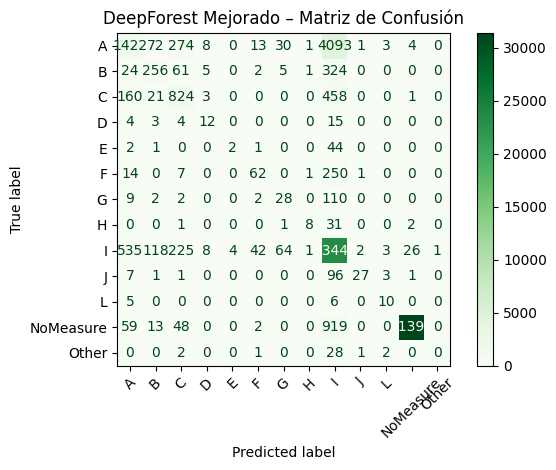

In [ ]:
# !pip install pandas numpy scikit-learn matplotlib -q

import os, time
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ─── 1) Configurar hilos ──────────────────────────
os.environ["OMP_NUM_THREADS"]      = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"]      = "8"

# ─── 2) Carga de datos y creación del target ───────
t0 = time.time()
df = pd.read_csv("todoscsvs_transformado.csv")
print(f"Datos cargados: {df.shape} en {time.time()-t0:.1f}s")

measures = list("ABCDEFGHIJKLMNÑO")
df["target"] = df[measures].idxmax(axis=1)
df.loc[df[measures].sum(axis=1)==0, "target"] = "NoMeasure"
rare = df["target"].value_counts()[lambda s: s<100].index
df["target"] = df["target"].where(~df["target"].isin(rare), "Other")

# ─── 3) Preprocesamiento ───────────────────────────
X = df.drop(columns=measures + ["target"])
y = LabelEncoder().fit_transform(df["target"])

# Imputar numéricos
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])

# Ordinal encode categóricas
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
if cat_cols:
    X[cat_cols] = OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1
    ).fit_transform(X[cat_cols].fillna("Missing"))

# ─── 4) Split train/test ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Split sizes → train={len(y_train)}, test={len(y_test)}")

# ─── 5) DeepForest mejorado ─────────────────────────
deepforest = RandomForestClassifier(
    n_estimators=500,            # más árboles para estabilidad
    max_depth=30,                # mayor profundidad controlada
    max_features=0.5,            # cada árbol ve la mitad de features
    min_samples_leaf=2,          # hojas mínimas de tamaño 2
    bootstrap=True,              # usar bootstrap
    max_samples=0.8,             # cada árbol usa el 80% de los datos
    class_weight="balanced_subsample",  # balanceo estratificado por submuestra
    oob_score=True,              # usar OOB para validación interna
    n_jobs=8,
    random_state=42
)

# Entrenamiento
t1 = time.time()
deepforest.fit(X_train, y_train)
print(f"DeepForest entrenado en {time.time()-t1:.1f}s")
print(f"OOB score: {deepforest.oob_score_:.4f}")

# Predicción y métricas
y_pred = deepforest.predict(X_test)
print("\n=== DeepForest Mejorado ===")
print("Accuracy     :", accuracy_score(y_test, y_pred))
print("Recall_macro :", recall_score(y_test, y_pred, average='macro'))
print("F1_weighted  :", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    cm, 
    display_labels=LabelEncoder().fit(df["target"]).classes_
)
disp.plot(cmap="Greens", xticks_rotation=45)
plt.title("DeepForest Mejorado – Matriz de Confusión")
plt.tight_layout()
plt.show()
